### Preparing dataset

In [1]:
import os
from pathlib import Path
import pandas as pd
import requests
import tiktoken
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import zipfile

In [2]:
# Download the file

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)


    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
      zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


In [ ]:
!head -n 50 sms_spam_collection/SMSSpamCollection.tsv

ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
ham	Ok lar... Joking wif u oni...
spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
ham	U dun say so early hor... U c already then say...
ham	Nah I don't think he goes to usf, he lives around here though
spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
ham	Even my brother is not like to speak with me. They treat me like aids patent.
ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune
spam	WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
spam	H

In [3]:
df = pd.read_csv(
    data_file_path,
    sep="\t",
    header=None,
    names=["Label", "Text"]
)
df, df.shape, df["Label"].value_counts()

(     Label                                               Text
 0      ham  Go until jurong point, crazy.. Available only ...
 1      ham                      Ok lar... Joking wif u oni...
 2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
 3      ham  U dun say so early hor... U c already then say...
 4      ham  Nah I don't think he goes to usf, he lives aro...
 ...    ...                                                ...
 5567  spam  This is the 2nd time we have tried 2 contact u...
 5568   ham               Will ü b going to esplanade fr home?
 5569   ham  Pity, * was in mood for that. So...any other s...
 5570   ham  The guy did some bitching but I acted like i'd...
 5571   ham                         Rofl. Its true to its name
 
 [5572 rows x 2 columns],
 (5572, 2),
 Label
 ham     4825
 spam     747
 Name: count, dtype: int64)

In [4]:
def create_balanced_dataset(df):
  spam = df[df['Label'] == 'spam']
  ham_subset = df[df['Label'] == 'ham'].sample(
      spam.shape[0], random_state=123
  )
  balanced_df = pd.concat([spam, ham_subset])
  return balanced_df


In [5]:
balanced_df = create_balanced_dataset(df)
balanced_df.shape, balanced_df['Label'].value_counts()

((1494, 2),
 Label
 spam    747
 ham     747
 Name: count, dtype: int64)

In [6]:
balanced_df['Label'] = balanced_df['Label'].map({'ham': 0, 'spam': 1})
balanced_df

,Label,Text
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
5,1,FreeMsg Hey there darling it's been 3 week's n...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...
11,1,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
4707,0,Wow so healthy. Old airport rd lor. Cant thk o...
3293,0,Dear good morning how you feeling dear
1278,0,Dont put your phone on silent mode ok
4079,0,Gam gone after outstanding innings.


In [ ]:
balanced_df, len(balanced_df)

(      Label                                               Text
 2         1  Free entry in 2 a wkly comp to win FA Cup fina...
 5         1  FreeMsg Hey there darling it's been 3 week's n...
 8         1  WINNER!! As a valued network customer you have...
 9         1  Had your mobile 11 months or more? U R entitle...
 11        1  SIX chances to win CASH! From 100 to 20,000 po...
 ...     ...                                                ...
 4707      0  Wow so healthy. Old airport rd lor. Cant thk o...
 3293      0             Dear good morning how you feeling dear
 1278      0              Dont put your phone on silent mode ok
 4079      0                Gam gone after outstanding innings.
 4468      0  She said,'' do u mind if I go into the bedroom...
 
 [1494 rows x 2 columns],
 1494)

In [7]:
def split_data(df, train_frac, val_frac):
  df = df.sample(
      frac=1,
      random_state=123
  ).reset_index(drop=True)

  train_end = int(train_frac * len(df))
  val_end = train_end + int(val_frac * len(df))

  train_ds = df[:train_end]
  val_ds = df[train_end:val_end]
  test_ds = df[val_end:]

  return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = split_data(balanced_df, 0.7, 0.2)

In [8]:
train_ds.to_csv('train.csv', index=None)
val_ds.to_csv('val.csv', index=None)
test_ds.to_csv('test.csv', index=None)

In [9]:
!cat test.csv

Label,Text
0,Y de asking like this.
0,Hey you told your name to gautham ah?
0,"Say this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,CLEAN MY HEART WITH YOUR BLOOD.Send this to Ten special people &amp; u c miracle tomorrow, do it,pls,pls do it..."
1,What do U want for Xmas? How about 100 free text messages & a new video phone with half price line rental? Call free now on 0800 0721072 to find out more!
1,"Had your mobile 10 mths? Update to the latest Camera/Video phones for FREE. KEEP UR SAME NUMBER, Get extra free mins/texts. Text YES for a call"
1,Camera - You are awarded a SiPix Digital Camera! call 09061221066 fromm landline. Delivery within 28 days.
0,"What i mean was i left too early to check, cos i'm working a 9-6."
1,GSOH? Good with SPAM the ladies?U could b a male gigolo? 2 join the uk's fastest growing mens club reply ONCALL. mjzgroup. 08714342399.2stop reply STOP. msg@£1.50rcvd
0,What happen dear. Why you silent. I am tensed
0,"Better than bb. If he wont use it, his wife will or 

In [10]:
# Defining Dataset and Dataloader

class SpamDataset(Dataset):
  def __init__(self, csv_file, tokenizer, max_length=None, pad_token=50256):
    self.data = pd.read_csv(csv_file)


    self.encoded_texts = [
        tokenizer.encode(text) for text in self.data["Text"]
    ]

    if not max_length:
      self.max_length = self._longest_encoded_length()
    else:
      self.max_length = max_length

    self.encoded_texts = [
      text[:self.max_length] for text in self.encoded_texts
    ]

    self.encoded_texts = [
        (text + [pad_token]*(self.max_length-len(text)))
        for text in self.encoded_texts
    ]

  def __getitem__(self, idx):
    return (
        torch.tensor(self.encoded_texts[idx], dtype=torch.long),
        torch.tensor(self.data.iloc[idx]["Label"], dtype=torch.long)
    )

  def __len__(self):
    return len(self.encoded_texts)

  def _longest_encoded_length(self):
    return max([len(encoded_text) for encoded_text in self.encoded_texts])

In [11]:
tokenizer = tiktoken.get_encoding('gpt2')
pad_token = tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'})
pad_token[0]

50256

In [12]:
train_dataset = SpamDataset(
    'train.csv',
    tokenizer
)

In [13]:
train_dataset.max_length

120

In [14]:
val_dataset = SpamDataset(
    'val.csv',
    tokenizer,
    max_length=train_dataset.max_length
)
test_dataset = SpamDataset(
    'test.csv',
    tokenizer,
    max_length=train_dataset.max_length
)


In [15]:
batch_size = 8

train_loader = DataLoader(
  train_dataset,
  batch_size=batch_size,
  num_workers=0,
  shuffle=True,
  drop_last=True
)

val_loader = DataLoader(
  val_dataset,
  batch_size=batch_size,
  num_workers=0,
  shuffle=False,
  drop_last=False
)

test_loader = DataLoader(
  test_dataset,
  batch_size=batch_size,
  num_workers=0,
  shuffle=False,
  drop_last=False
)

In [16]:
print(len(train_loader), len(val_loader), len(test_loader))
xtr, ytr = next(iter(train_loader))
xtr.shape, ytr.shape

130 38 19


(torch.Size([8, 120]), torch.Size([8]))

### Loading model with pretrained weights

In [17]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim, eps=1e-5):
    super().__init__()
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))
    self.eps = eps

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False) # divide by n here to be consistent with what was used in GPT2
    x = (x-mean)/torch.sqrt(var + self.eps)
    x = x*self.scale + self.shift
    return x


class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    x = 0.5 * x * (1 + torch.tanh(
          torch.sqrt(torch.tensor(2)/torch.pi) * (x + 0.044715*(x**3))
        ))
    return x


class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    emb_dim = cfg["emb_dim"]
    self.layers = nn.Sequential(
        nn.Linear(emb_dim, 4*emb_dim),
        GELU(),
        nn.Linear(4*emb_dim, emb_dim)
    )

  def forward(self, x):
    return self.layers(x)


class MultiHeadAttention(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    d_in, d_out = cfg["emb_dim"], cfg["emb_dim"]
    context_length = cfg["context_length"]
    dropout = cfg["drop_rate"]
    num_heads = cfg["n_heads"]
    qkv_bias = cfg["qkv_bias"]

    assert(d_out % num_heads == 0)

    self.head_dim = d_out // num_heads
    self.num_heads = num_heads

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )
    self.projection = nn.Linear(d_out, d_out)

  def forward(self, x):
    # x -> [B, T, d_in]
    B, T, d_in = x.shape

    queries = self.W_query(x)
    keys = self.W_key(x)
    values = self.W_value(x)

    queries = queries.view(B, T, self.num_heads, self.head_dim) # [B, T, NH, HD]
    queries = queries.transpose(1, 2) # [B, NH, T, HD]
    keys = keys.view(B, T, self.num_heads, self.head_dim) # [B, T, NH, HD]
    keys = keys.transpose(1, 2) # [B, NH, T, HD]
    values = values.view(B, T, self.num_heads, self.head_dim)
    values = values.transpose(1, 2) # [B, NH, T, HD]

    attn_scores = queries @ keys.transpose(2, 3) # [B, NH, T, T]
    attn_scores.masked_fill_(self.mask.bool()[:T,:T], -torch.inf)
    attn_weights = torch.softmax(attn_scores/self.head_dim**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vecs = attn_weights @ values # [B, NH, T, HD]
    context_vecs = context_vecs.transpose(1,2).reshape(B, T, -1)
    # Reshape instead of view because view needs contiguous
    # Alternative context_vecs.contiguous().view(B, T, -1)
    context_vecs = self.projection(context_vecs) # [B, T, d_out]
    return context_vecs



class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.attn_block = MultiHeadAttention(cfg)
    self.ffwd = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.layer_norm1 = LayerNorm(cfg["emb_dim"])
    self.layer_norm2 = LayerNorm(cfg["emb_dim"])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.attn_block(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffwd(x)
    x = self.dropout(x)
    x = x + shortcut

    return x


class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_embedding = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.layer_norm = LayerNorm(cfg["emb_dim"])
    self.transformer_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False) # Weight reused here in Open AI GPT2

  def forward(self, x):
    # x.shape [B, T]
    B, T = x.shape
    token_embd = self.token_embedding(x) # [B, T, E]  E -> emb_dim
    pos_embd = self.pos_embedding(torch.arange(0, T).to(device)) # [T, E]
    x = token_embd + pos_embd # [T, E] broadcasted to [B, T, E] and then add
    x = self.dropout(x)
    x = self.transformer_blocks(x)
    x = self.layer_norm(x)
    x = self.out_head(x)
    return x


In [18]:
def text_to_token_ids(text, tokenizer):
  token_ids = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  token_ids = torch.tensor(token_ids).unsqueeze(0)
  return token_ids

def token_ids_to_text(token_ids, tokenizer):
  text = tokenizer.decode(token_ids.squeeze(0).tolist())
  return text

def generate_text_simple(input_batch, model, context_length, device, max_tokens=50):
  for _ in range(max_tokens):
    input_batch = input_batch[:, -context_length:]
    input_batch = input_batch.to(device)
    model = model.to(device)
    with torch.no_grad():
      logits = model(input_batch)
    probs = torch.softmax(logits[:,-1,:], dim=-1)
    next = torch.argmax(probs, dim=-1, keepdim=True)
    input_batch = torch.cat([input_batch, next], dim=1)

  return input_batch

In [19]:
import urllib.request

url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch05/01_main-chapter-code/gpt_download.py"
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)


from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

def assign(left, right):

  if left.shape != right.shape:
    raise ValueError(f"Shape mismatch {left.shape} {right.shape}")

  return torch.nn.Parameter(torch.tensor(right))

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 46.0kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 569kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 178kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [02:39<00:00, 3.12MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 11.8MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 339kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 458kiB/s]


In [21]:
GPT_CONFIG_124M = {
  "vocab_size": 50257,
  "context_length": 1024, # using a smaller size for testing
  "emb_dim": 768,
  "n_heads": 12,
  "n_layers": 12,
  "drop_rate": 0.1,
  "qkv_bias": False
}

In [22]:
import numpy as np

def load_openai_weights(model, params):
  model.token_embedding.weight = assign(model.token_embedding.weight, params["wte"])
  model.pos_embedding.weight = assign(model.pos_embedding.weight, params["wpe"])

  for idx in range(len(model.transformer_blocks)):

    # Layer Norm 1
    model.transformer_blocks[idx].layer_norm1.scale = assign(
        model.transformer_blocks[idx].layer_norm1.scale,
        params["blocks"][idx]["ln_1"]["g"]
    )
    model.transformer_blocks[idx].layer_norm1.shift = assign(
        model.transformer_blocks[idx].layer_norm1.shift,
        params["blocks"][idx]["ln_1"]["b"]
    )

    # Attention
    W_Q, W_K, W_V = np.split(params["blocks"][idx]["attn"]["c_attn"]["w"], 3, axis=-1)
    B_Q, B_K, B_V = np.split(params["blocks"][idx]["attn"]["c_attn"]["b"], 3, axis=-1)

    model.transformer_blocks[idx].attn_block.W_query.weight = assign(
        model.transformer_blocks[idx].attn_block.W_query.weight,
        W_Q.T
    )
    model.transformer_blocks[idx].attn_block.W_query.bias = assign(
        model.transformer_blocks[idx].attn_block.W_query.bias,
        B_Q.T
    )
    model.transformer_blocks[idx].attn_block.W_key.weight = assign(
        model.transformer_blocks[idx].attn_block.W_key.weight,
        W_K.T
    )
    model.transformer_blocks[idx].attn_block.W_key.bias = assign(
        model.transformer_blocks[idx].attn_block.W_key.bias,
        B_K
    )
    model.transformer_blocks[idx].attn_block.W_value.weight = assign(
        model.transformer_blocks[idx].attn_block.W_value.weight,
        W_V.T
    )
    model.transformer_blocks[idx].attn_block.W_value.bias = assign(
        model.transformer_blocks[idx].attn_block.W_value.bias,
        B_V
    )

    model.transformer_blocks[idx].attn_block.projection.weight = assign(
        model.transformer_blocks[idx].attn_block.projection.weight,
        params["blocks"][idx]["attn"]["c_proj"]["w"].T
    )
    model.transformer_blocks[idx].attn_block.projection.bias = assign(
        model.transformer_blocks[idx].attn_block.projection.bias,
        params["blocks"][idx]["attn"]["c_proj"]["b"]
    )

    # Layer Norm 2
    model.transformer_blocks[idx].layer_norm2.scale = assign(
        model.transformer_blocks[idx].layer_norm2.scale,
        params["blocks"][idx]["ln_2"]["g"]
    )
    model.transformer_blocks[idx].layer_norm2.shift = assign(
        model.transformer_blocks[idx].layer_norm2.shift,
        params["blocks"][idx]["ln_2"]["b"]
    )

    # Feed Forward
    model.transformer_blocks[idx].ffwd.layers[0].weight = assign(
        model.transformer_blocks[idx].ffwd.layers[0].weight,
        params["blocks"][idx]["mlp"]["c_fc"]["w"].T
    )
    model.transformer_blocks[idx].ffwd.layers[0].bias = assign(
        model.transformer_blocks[idx].ffwd.layers[0].bias,
        params["blocks"][idx]["mlp"]["c_fc"]["b"]
    )
    model.transformer_blocks[idx].ffwd.layers[2].weight = assign(
        model.transformer_blocks[idx].ffwd.layers[2].weight,
        params["blocks"][idx]["mlp"]["c_proj"]["w"].T
    )
    model.transformer_blocks[idx].ffwd.layers[2].bias = assign(
        model.transformer_blocks[idx].ffwd.layers[2].bias,
        params["blocks"][idx]["mlp"]["c_proj"]["b"]
    )


  # Final Layer Norm
  model.layer_norm.scale = assign(
      model.layer_norm.scale,
      params["g"]
  )
  model.layer_norm.shift = assign(
      model.layer_norm.shift,
      params["b"]
  )

  # Out head
  model.out_head.weight = assign(
      model.out_head.weight,
      params["wte"] # Reuses weights from token embedding layer
  )

In [40]:
GPT_CONFIG_124M.update({"context_length": 1024, "qkv_bias": True})
model = GPTModel(GPT_CONFIG_124M)
print(GPT_CONFIG_124M)

load_openai_weights(model, params)

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True}


In [33]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()
token_ids = generate_text_simple(
    text_to_token_ids("Every effort moves you", tokenizer),
    model,
    1024,
    device,
    max_tokens=15
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [ ]:
# Verifying if the model is already capable of classifying spam
sample_spam_text = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    text_to_token_ids(sample_spam_text, tokenizer),
    model,
    1024,
    device,
    max_tokens=23
)
print(token_ids_to_text(token_ids, tokenizer))


Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


### Adding a classification head

In [ ]:
model

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (pos_embedding): Embedding(1024, 768)
  (layer_norm): LayerNorm()
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn_block): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (projection): Linear(in_features=768, out_features=768, bias=True)
      )
      (ffwd): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
    )
    (1): TransformerBlock(
      (attn_block): MultiHeadAttention(
        (

In [41]:
# Freezing all parameters first
for p in model.parameters():
  p.requires_grad = False

In [42]:
num_classes = 2 # 0-ham, 1-spam

model.out_head = nn.Linear(  # By default requires_grad is set to True
    GPT_CONFIG_124M["emb_dim"],
    num_classes
)

# Additionally setting last transformer block and last layer norm to be trainable as well
for p in model.transformer_blocks[-1].parameters():
  p.requires_grad = True
for p in model.layer_norm.parameters():
  p.requires_grad = True

In [ ]:
# Testing setup
inputs = text_to_token_ids("Do you have time", tokenizer)
inputs.shape

torch.Size([1, 4])

In [ ]:
inputs = inputs.to(device)
model = model.to(device)
output_logits = model(inputs)
output_logits, output_logits.shape

(tensor([[[-0.2157, -1.5900],
          [ 2.3430, -6.5703],
          [ 1.4518, -5.4745],
          [-0.5115, -3.4050]]], device='cuda:0', grad_fn=<ViewBackward0>),
 torch.Size([1, 4, 2]))

In [ ]:
# Just using the last token
logits = output_logits[:,-1,:]
probs = torch.softmax(logits, dim=-1)
print(probs.shape, probs)
label = torch.argmax(probs, dim=-1)
print(label.shape, label)
print(label.item())

torch.Size([1, 2]) tensor([[0.9475, 0.0525]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
torch.Size([1]) tensor([0], device='cuda:0')
0


### Calculating accuracy and loss before training on loaded weights

In [30]:
def calc_accuracy_loader(dataloader, model, device, num_batches=None):
  model.eval()
  model = model.to(device)
  correct, total = 0., 0.

  if not num_batches:
    num_batches = len(dataloader)
  else:
    num_batches = min(num_batches, len(dataloader))

  for i, (x,y) in enumerate(dataloader):
    if i < num_batches:
      x = x.to(device) # [B, T]
      y = y.to(device) # [B]

      with torch.no_grad():
        logits = model(x) # [B, T, 2]

      logits = logits[:, -1, :] # [B, 2]
      preds = torch.argmax(logits, dim=-1) #[B]

      total += x.shape[0]
      correct += (preds == y).sum().item()

  return correct/total

In [ ]:
print(f"Train accuracy: {calc_accuracy_loader(train_loader, model, device)}")
print(f"Val accuracy: {calc_accuracy_loader(val_loader, model, device)}")
print(f"Test accuracy: {calc_accuracy_loader(test_loader, model, device)}")

Train accuracy: 0.49615384615384617
Val accuracy: 0.5033557046979866
Test accuracy: 0.5298013245033113


In [ ]:
def calc_loss_batch(input_batch, target_batch, model):
  logits = model(input_batch)[:,-1,:] # [B, 2]
  loss = F.cross_entropy(logits, target_batch)
  return loss

In [31]:
def calc_loss_loader(dataloader, model, device, num_batches=None):
  model.eval()
  model = model.to(device)
  total_loss = 0.

  if not num_batches:
    num_batches = len(dataloader)
  else:
    num_batches = min(num_batches, len(dataloader))

  for i, (x,y) in enumerate(dataloader):
    if i < num_batches:
      x = x.to(device) # [B, T]
      y = y.to(device) # [B]

      with torch.no_grad():
        loss = calc_loss_batch(x, y, model)

      total_loss += loss.item()

  return total_loss/num_batches

In [ ]:
print(f"Train loss: {calc_loss_loader(train_loader, model, device)}")
print(f"Val loss: {calc_loss_loader(val_loader, model, device)}")
print(f"Test loss: {calc_loss_loader(test_loader, model, device)}")

Train loss: 2.3867553489497646
Val loss: 2.3367439367269216
Test loss: 2.2058048844337463


### Finetuning model to classify spam

In [ ]:
def classify_review(
    text,
    model,
    tokenizer,
    pad_token_id=50256,
    max_length=120 # Max length seen in train ds
):
  model.eval()
  token_ids = tokenizer.encode(text)
  context_length = model.pos_embedding.weight.shape[0] # context_length x emb_dim
  context_length = min(max_length, context_length)
  token_ids = token_ids[:context_length]
  padded_token_ids = token_ids + [pad_token_id] * (context_length - len(token_ids))

  input_batch = torch.tensor(padded_token_ids).unsqueeze(0).to(device)

  with torch.no_grad():
    logits = model(input_batch)[:, -1, :]
  label = torch.argmax(logits, dim=-1).item()
  print(label)
  result = 'Spam' if label == 1 else 'Not Spam'
  return result


In [ ]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_1,
    model,
    tokenizer
))

print(classify_review(
    text_2,
    model,
    tokenizer
))

0
Not Spam
0
Not Spam


In [28]:
# Training code

def train_classifier_model(
    model,
    optimizer,
    train_dataloader,
    val_dataloader,
    device,
    num_epochs,
    eval_freq,
    eval_iter
):

  model = model.to(device)
  examples_seen = 0
  global_step = 0
  train_accs, val_accs = [], []
  train_losses, val_losses = [], []

  for _ in range(num_epochs):

    model.train()

    for x,y in train_dataloader:
      x = x.to(device)
      y = y.to(device)

      loss = calc_loss_batch(x,y,model)

      optimizer.zero_grad()
      loss.backward()

      optimizer.step()
      global_step += 1
      examples_seen += x.shape[0]

      if global_step % eval_freq == 0:
        train_loss = calc_loss_loader(train_dataloader, model, device, eval_iter)
        val_loss = calc_loss_loader(val_dataloader, model, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Step {global_step} Train loss {train_loss} Val loss {val_loss}")

    train_acc = calc_accuracy_loader(train_dataloader, model, device, eval_iter)
    val_acc = calc_accuracy_loader(val_dataloader, model, device, eval_iter)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Step {global_step} Train acc {train_acc} Val acc {val_acc}")

  return train_losses, val_losses, train_accs, val_accs, examples_seen

In [ ]:
torch.manual_seed(123)

start_time = time.time()
optimizer = torch.optim.AdamW(
    params=model.parameters(),
    lr=5e-5,
    weight_decay=0.1
)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    device,
    num_epochs,
    eval_freq=50,
    eval_iter=5
)

end_time = time.time()
execution_time = (end_time - start_time)/60
print(f"Total training time : {execution_time: .2f} minutes")

Step 50 Train loss 0.7007935166358947 Val loss 0.7418461918830872
Step 100 Train loss 0.606517219543457 Val loss 0.5878875374794006
Step 130 Train acc 0.7 Val acc 0.725
Step 150 Train loss 0.5205487787723542 Val loss 0.5361895799636841
Step 200 Train loss 0.31893770694732665 Val loss 0.29994405508041383
Step 250 Train loss 0.15469975471496583 Val loss 0.14341114684939385
Step 260 Train acc 0.975 Val acc 0.925
Step 300 Train loss 0.18735162168741226 Val loss 0.12358773611485958
Step 350 Train loss 0.047863693162798884 Val loss 0.09523688927292824
Step 390 Train acc 0.95 Val acc 0.95
Step 400 Train loss 0.06382672227919102 Val loss 0.08749128244817257
Step 450 Train loss 0.07652273001149297 Val loss 0.07778487578034401
Step 500 Train loss 0.08048467952758073 Val loss 0.07638635095208883
Step 520 Train acc 1.0 Val acc 0.95
Step 550 Train loss 0.017577661760151388 Val loss 0.0884440779685974
Step 600 Train loss 0.057978538889437915 Val loss 0.07328161736950278
Step 650 Train loss 0.0183834

In [36]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

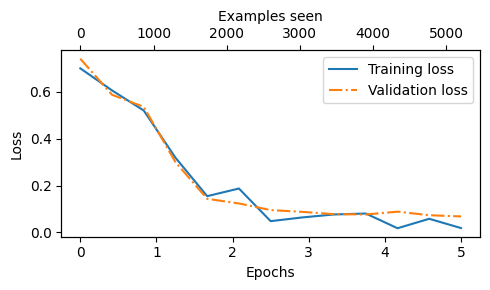

In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

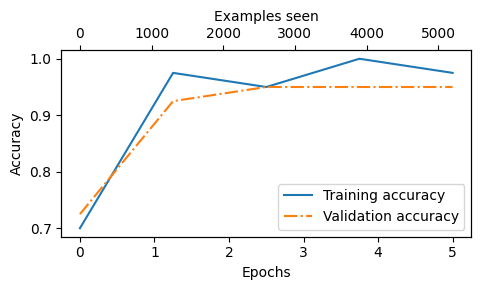

In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [ ]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

text_3 = "Hey you told your name to gautham ah?"

print(classify_review(
    text_1,
    model,
    tokenizer
))

print(classify_review(
    text_2,
    model,
    tokenizer
))

print(classify_review(
    text_3,
    model,
    tokenizer
))

1
Spam
0
Not Spam
0
Not Spam


### EXERCISE 6.3
Fine tune first token instead of last token

In [43]:
def calc_accuracy_loader(dataloader, model, device, num_batches=None):
  model.eval()
  model = model.to(device)
  correct, total = 0., 0.

  if not num_batches:
    num_batches = len(dataloader)
  else:
    num_batches = min(num_batches, len(dataloader))

  for i, (x,y) in enumerate(dataloader):
    if i < num_batches:
      x = x.to(device) # [B, T]
      y = y.to(device) # [B]

      with torch.no_grad():
        logits = model(x) # [B, T, 2]

      logits = logits[:, 0, :] # [B, 2]
      preds = torch.argmax(logits, dim=-1) #[B]

      total += x.shape[0]
      correct += (preds == y).sum().item()

  return correct/total


def calc_loss_batch(input_batch, target_batch, model):
  logits = model(input_batch)[:,0,:] # [B, 2]
  loss = F.cross_entropy(logits, target_batch)
  return loss


def calc_loss_loader(dataloader, model, device, num_batches=None):
  model.eval()
  model = model.to(device)
  total_loss = 0.

  if not num_batches:
    num_batches = len(dataloader)
  else:
    num_batches = min(num_batches, len(dataloader))

  for i, (x,y) in enumerate(dataloader):
    if i < num_batches:
      x = x.to(device) # [B, T]
      y = y.to(device) # [B]

      with torch.no_grad():
        loss = calc_loss_batch(x, y, model)

      total_loss += loss.item()

  return total_loss/num_batches


torch.manual_seed(123)
start_time = time.time()
optimizer = torch.optim.AdamW(
    params=model.parameters(),
    lr=5e-5,
    weight_decay=0.1
)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    device,
    num_epochs,
    eval_freq=50,
    eval_iter=5
)

end_time = time.time()
execution_time = (end_time - start_time)/60
print(f"Total training time : {execution_time: .2f} minutes")

Step 50 Train loss 0.6635735034942627 Val loss 0.7339539647102356
Step 100 Train loss 0.6708877444267273 Val loss 0.6931000590324402
Step 130 Train acc 0.45 Val acc 0.5
Step 150 Train loss 0.6543329000473023 Val loss 0.6971548438072205
Step 200 Train loss 0.6132594823837281 Val loss 0.6886938810348511
Step 250 Train loss 0.6037703514099121 Val loss 0.6936524391174317
Step 260 Train acc 0.675 Val acc 0.5
Step 300 Train loss 0.6744855642318726 Val loss 0.6875846743583679
Step 350 Train loss 0.6084038734436035 Val loss 0.6780698418617248
Step 390 Train acc 0.625 Val acc 0.525
Step 400 Train loss 0.6325752377510071 Val loss 0.6643287539482117
Step 450 Train loss 0.6449723839759827 Val loss 0.6634660363197327
Step 500 Train loss 0.6411792159080505 Val loss 0.660065495967865
Step 520 Train acc 0.65 Val acc 0.55
Step 550 Train loss 0.6167914986610412 Val loss 0.6620369672775268
Step 600 Train loss 0.529202687740326 Val loss 0.6401368260383606
Step 650 Train loss 0.5464579164981842 Val loss 0.

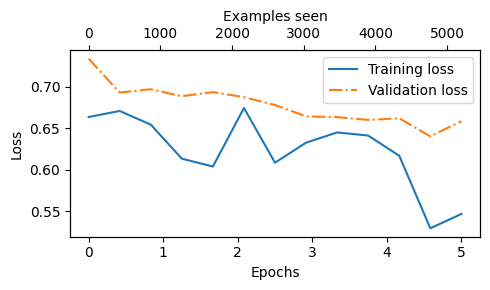

In [44]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

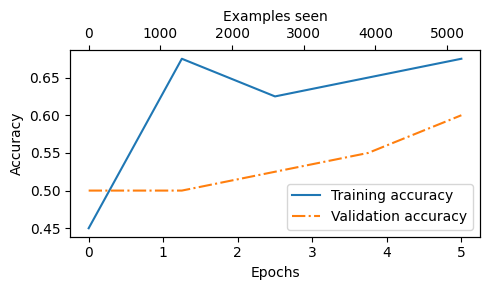

In [45]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [46]:
def classify_review(
    text,
    model,
    tokenizer,
    pad_token_id=50256,
    max_length=120 # Max length seen in train ds
):
  model.eval()
  token_ids = tokenizer.encode(text)
  context_length = model.pos_embedding.weight.shape[0] # context_length x emb_dim
  context_length = min(max_length, context_length)
  token_ids = token_ids[:context_length]
  padded_token_ids = token_ids + [pad_token_id] * (context_length - len(token_ids))

  input_batch = torch.tensor(padded_token_ids).unsqueeze(0).to(device)

  with torch.no_grad():
    logits = model(input_batch)[:, 0, :]
  label = torch.argmax(logits, dim=-1).item()
  print(label)
  result = 'Spam' if label == 1 else 'Not Spam'
  return result


In [47]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

text_3 = "Hey you told your name to him ah?"

print(classify_review(
    text_1,
    model,
    tokenizer
))

print(classify_review(
    text_2,
    model,
    tokenizer
))

print(classify_review(
    text_3,
    model,
    tokenizer
))

0
Not Spam
0
Not Spam
0
Not Spam
